In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV, GridSearchCV, KFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

from xgboost import XGBRegressor, plot_importance


In [37]:
df = pd.read_csv("strong_diabetes_dataset_300_utf8.csv")

print("Dataset Shape:", df.shape)
print(df.head())


Dataset Shape: (300, 11)
   Gender Physical_Activity_Level Smoking_Habits Alcohol_Consumption  \
0  Female               Sedentary          Never          Occasional   
1    Male               Sedentary          Never               Never   
2    Male                Moderate     Occasional             Regular   
3  Female                  Active          Never             Regular   
4  Female                Moderate     Occasional             Regular   

  Family_Diabetes_History Stress_Level Sleep_Pattern  Height_cm  Weight_kg  \
0                    Both          Low           <5h     143.93      44.14   
1                Paternal     Moderate          7-8h     172.13      85.48   
2                     NaN     Moderate           >8h     172.49      71.80   
3                Paternal     Moderate          7-8h     166.09      71.09   
4                    Both     Moderate          5-6h     156.40      93.03   

     BMI  Age_of_Onset  
0  21.30         24.76  
1  28.85         25.08 

In [3]:
numerical_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()

print("Numerical Columns:", numerical_cols)
print("Categorical Columns:", categorical_cols)


Numerical Columns: ['Height_cm', 'Weight_kg', 'BMI', 'Age_of_Onset']
Categorical Columns: ['Gender', 'Physical_Activity_Level', 'Smoking_Habits', 'Alcohol_Consumption', 'Family_Diabetes_History', 'Stress_Level', 'Sleep_Pattern']


In [38]:
target_col = df.columns[-1]
print("Target Column:", target_col)

# Remove target from lists
if target_col in numerical_cols:
    numerical_cols.remove(target_col)

if target_col in categorical_cols:
    categorical_cols.remove(target_col)


Target Column: Age_of_Onset


In [5]:
# Remove missing values
df = df.dropna()


In [6]:
df_encoded = df.copy()

for col in df_encoded.columns:
    if df_encoded[col].dtype == 'object':
        le = LabelEncoder()
        df_encoded[col] = le.fit_transform(df_encoded[col])


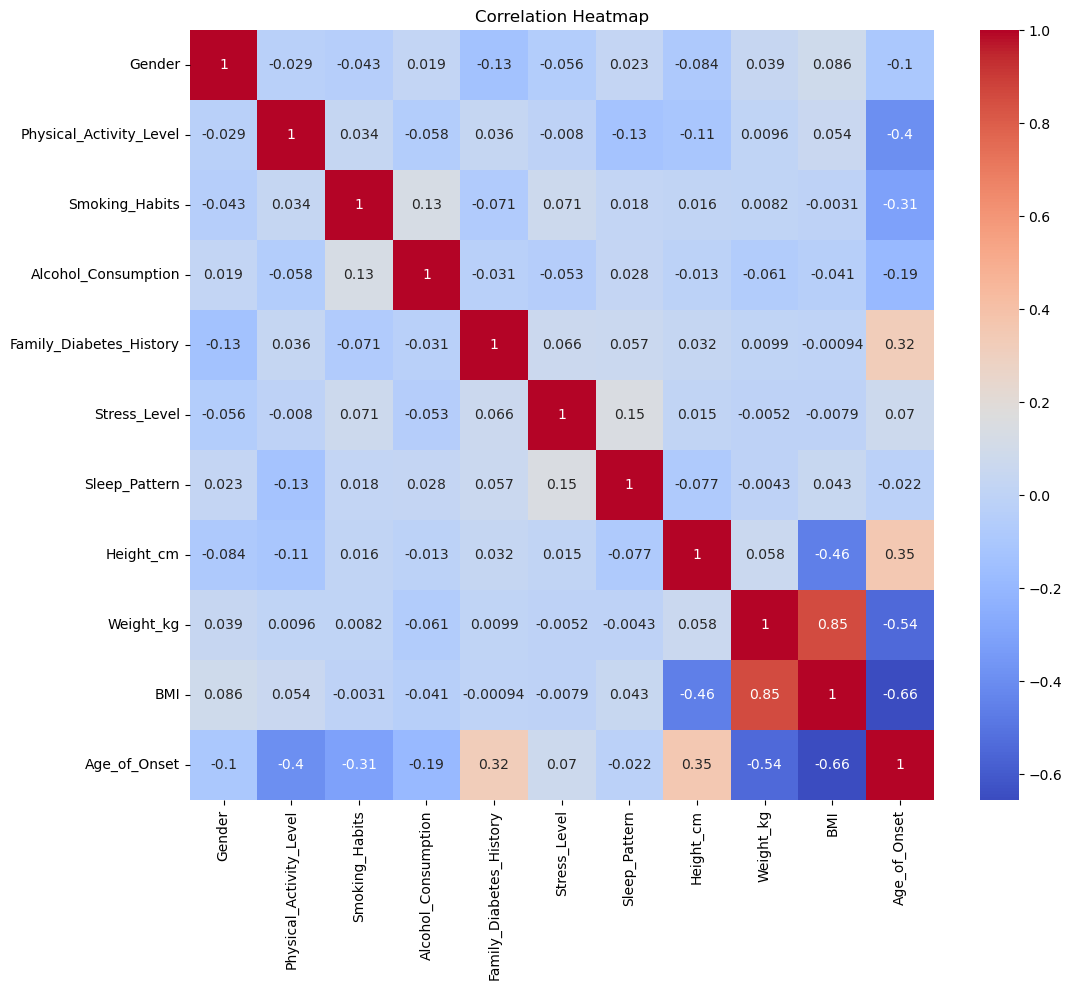

In [7]:
plt.figure(figsize=(12,10))
sns.heatmap(df_encoded.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


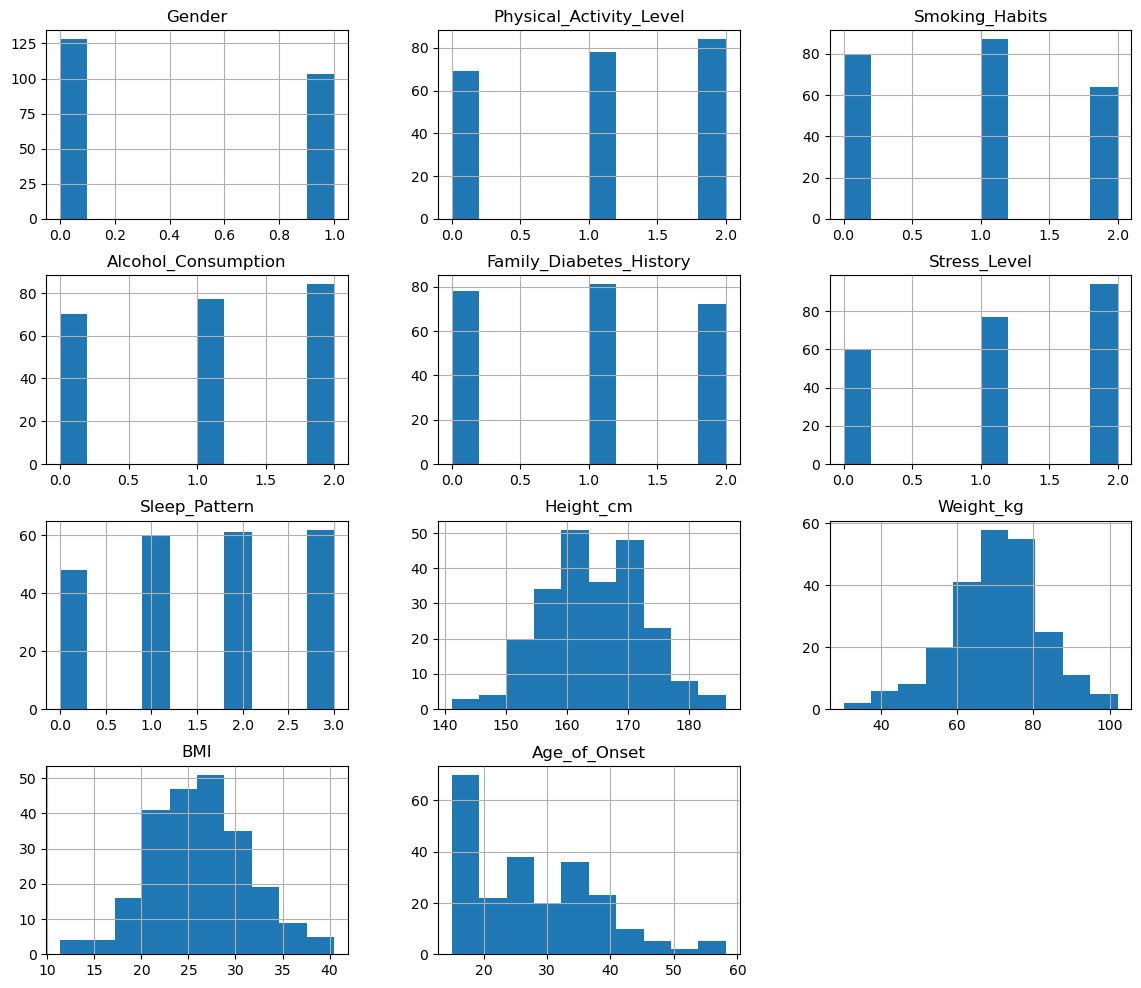

In [8]:
df_encoded.hist(figsize=(14,12))
plt.show()


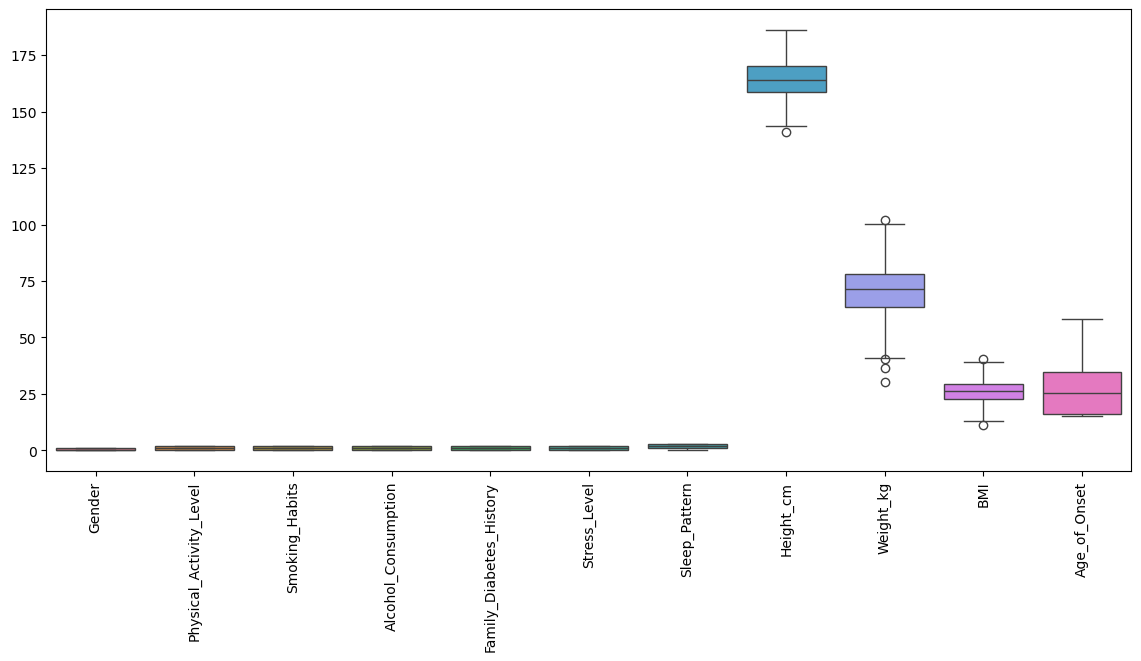

In [9]:
plt.figure(figsize=(14,6))
sns.boxplot(data=df_encoded)
plt.xticks(rotation=90)
plt.show()


In [10]:
target_col = df_encoded.columns[-1]

X = df_encoded.drop(target_col, axis=1)
y = df_encoded[target_col]

print("Target Column:", target_col)


Target Column: Age_of_Onset


In [11]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)


In [13]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR

models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest": RandomForestRegressor(),
    "Support Vector": SVR(),
    "XGBoost": XGBRegressor(random_state=42)
}

results = []

for name, model in models.items():
    
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    
    r2 = r2_score(y_test, preds)
    mae = mean_absolute_error(y_test, preds)
    mse = mean_squared_error(y_test, preds)
    rmse = np.sqrt(mse)
    
    results.append([name, r2, mae, mse, rmse])

results_df = pd.DataFrame(results, columns=["Model", "R2", "MAE", "MSE", "RMSE"])

results_df = results_df.sort_values(by="R2", ascending=False)

print(results_df)


               Model        R2       MAE        MSE      RMSE
0  Linear Regression  0.804374  3.758850  19.903101  4.461289
2      Random Forest  0.672756  4.475530  33.293965  5.770092
4            XGBoost  0.633466  4.848391  37.291267  6.106658
3     Support Vector  0.579760  5.233011  42.755342  6.538757
1      Decision Tree  0.365129  6.068936  64.591940  8.036911


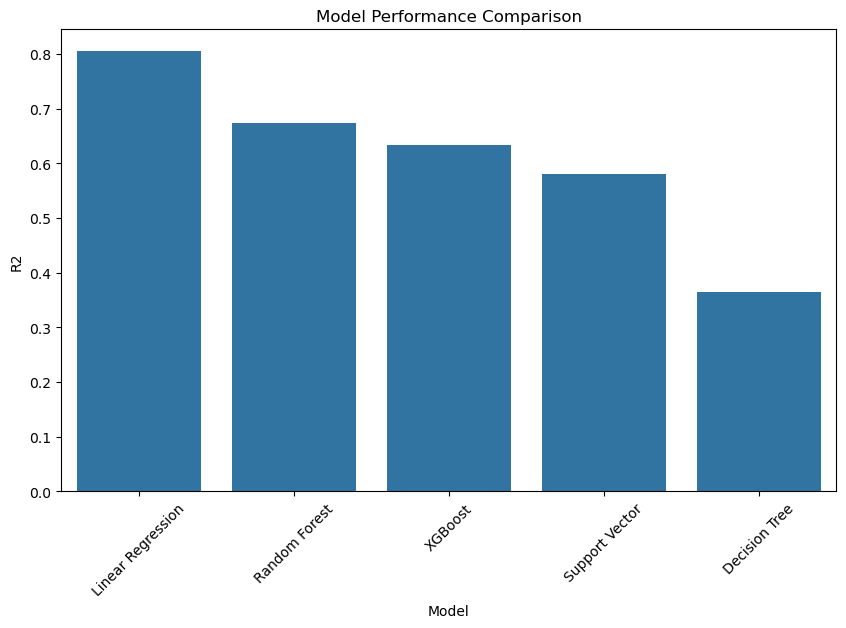

In [14]:
plt.figure(figsize=(10,6))
sns.barplot(x="Model", y="R2", data=results_df)
plt.title("Model Performance Comparison")
plt.xticks(rotation=45)
plt.show()


In [15]:
baseline_model = XGBRegressor(random_state=42)
baseline_model.fit(X_train, y_train)

y_pred = baseline_model.predict(X_test)

print("Baseline R2:", r2_score(y_test, y_pred))
print("Baseline RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))


Baseline R2: 0.6334662507160129
Baseline RMSE: 6.106657566753102


In [16]:
param_dist = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [3, 5, 7, 10],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "gamma": [0, 0.1, 0.2],
    "reg_alpha": [0, 0.1, 1],
    "reg_lambda": [1, 2, 5]
}

xgb = XGBRegressor(random_state=42)

random_search = RandomizedSearchCV(
    xgb,
    param_dist,
    n_iter=50,
    cv=5,
    scoring="r2",
    verbose=1,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

print("Best Parameters:", random_search.best_params_)


Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best Parameters: {'subsample': 0.6, 'reg_lambda': 5, 'reg_alpha': 0, 'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.1, 'gamma': 0, 'colsample_bytree': 0.6}


In [17]:
best_params = random_search.best_params_

grid_param = {
    "n_estimators": [best_params["n_estimators"]-50,
                     best_params["n_estimators"],
                     best_params["n_estimators"]+50],

    "max_depth": [best_params["max_depth"]-1,
                  best_params["max_depth"],
                  best_params["max_depth"]+1],

    "learning_rate": [best_params["learning_rate"]*0.5,
                      best_params["learning_rate"],
                      best_params["learning_rate"]*1.5]
}

grid_search = GridSearchCV(
    XGBRegressor(**best_params, random_state=42),
    grid_param,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Final Parameters:", grid_search.best_params_)


Final Parameters: {'learning_rate': 0.1, 'max_depth': 2, 'n_estimators': 250}


In [18]:
final_model = grid_search.best_estimator_
final_model.fit(X_train, y_train)

y_pred = final_model.predict(X_test)


In [19]:
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

results = pd.DataFrame({
    "Metric": ["R2 Score", "MAE", "RMSE"],
    "Value": [r2, mae, rmse]
})

print(results)


     Metric     Value
0  R2 Score  0.818666
1       MAE  3.677622
2      RMSE  4.295228


In [20]:
kf = KFold(n_splits=10, shuffle=True, random_state=42)

scores = []

for train_idx, test_idx in kf.split(X_scaled):
    X_train_cv, X_test_cv = X_scaled[train_idx], X_scaled[test_idx]
    y_train_cv, y_test_cv = y.iloc[train_idx], y.iloc[test_idx]
    
    final_model.fit(X_train_cv, y_train_cv)
    preds = final_model.predict(X_test_cv)
    
    scores.append(r2_score(y_test_cv, preds))

print("Cross Validation R2:", np.mean(scores))


Cross Validation R2: 0.8474055527995734


<Figure size 1000x700 with 0 Axes>

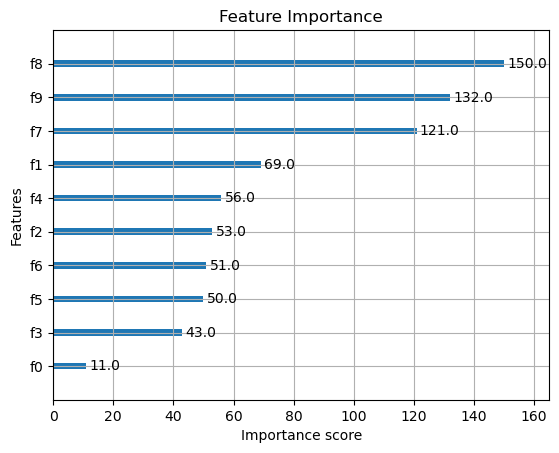

In [21]:
plt.figure(figsize=(10,7))
plot_importance(final_model)
plt.title("Feature Importance")
plt.show()


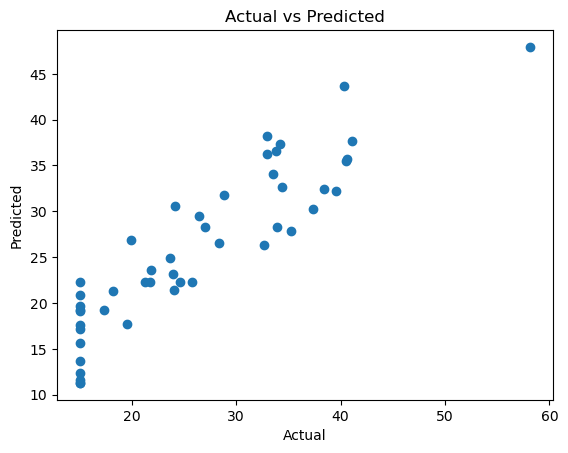

In [22]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()


In [23]:
print("Total missing values:", df.isnull().sum().sum())

Total missing values: 0


In [24]:
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="mean")),
            ("scaler", StandardScaler())
        ]), numerical_cols),

        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder", OneHotEncoder(handle_unknown="ignore"))
        ]), categorical_cols)
    ]
)


In [39]:
X = df.drop(target_col, axis=1)
y = df[target_col]

X_processed = preprocessor.fit_transform(X)


In [40]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_processed, y, test_size=0.2, random_state=42
)


In [43]:

X = df.drop("Age_of_Onset", axis=1)
y = df["Age_of_Onset"]


In [44]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [45]:
print(type(X_train))


<class 'pandas.core.frame.DataFrame'>


In [27]:
from sklearn.model_selection import cross_val_score

model = XGBRegressor(random_state=42)

scores = cross_val_score(model, X_processed, y, cv=5, scoring="r2")

print("CV R2 Scores:", scores)
print("Mean CV R2:", scores.mean())



CV R2 Scores: [0.74956786 0.81240506 0.58178406 0.77562361 0.81269329]
Mean CV R2: 0.7464147764167958


In [28]:
from xgboost import XGBRegressor

model = XGBRegressor(random_state=42)

model.fit(X_train, y_train)

preds = model.predict(X_test)


In [29]:
from sklearn.feature_selection import RFE

rfe = RFE(model, n_features_to_select=8)

rfe.fit(X_train, y_train)

print("Selected Features:", rfe.support_)


Selected Features: [False False  True False False  True False  True False False False  True
 False  True  True False False False  True False False False  True False]


In [30]:
from sklearn.ensemble import RandomForestRegressor, StackingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor

base_estimators = [
    ("rf", RandomForestRegressor(random_state=42)),
    ("xgb", XGBRegressor(random_state=42)),
    ("dt", DecisionTreeRegressor(random_state=42))
]

stack_model = StackingRegressor(
    estimators=base_estimators,
    final_estimator=LinearRegression()
)

stack_model.fit(X_train, y_train)

preds = stack_model.predict(X_test)


In [31]:
from sklearn.metrics import r2_score, mean_squared_error

print("Stacking R2:", r2_score(y_test, preds))
print("Stacking RMSE:", np.sqrt(mean_squared_error(y_test, preds)))


Stacking R2: 0.6494573020858156
Stacking RMSE: 5.971962131966235


In [32]:
from sklearn.ensemble import RandomForestRegressor, StackingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor
from sklearn.pipeline import Pipeline


In [33]:
base_estimators = [
    ("rf", RandomForestRegressor(random_state=42)),
    ("xgb", XGBRegressor(random_state=42)),
    ("dt", DecisionTreeRegressor(random_state=42))
]

stack_model = StackingRegressor(
    estimators=base_estimators,
    final_estimator=LinearRegression()
)

stack_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", stack_model)
])


In [34]:
stack_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", stack_model)
])


In [46]:
stack_pipeline.fit(X_train, y_train)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Height_cm', 'Weight_kg',
                                                   'BMI']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Gender',
                                                   'Physical_Activity_Level',
                                                   'Smoking...
                                                             learning_rate=None,
                                                             max_bin=None,
                                                             max_cat_threshold=None,
                                                             max_cat_to_onehot=None,
                                                             max_delta_step=None,
                                                             max_depth=None,
                                                             max_leaves=None,
                                                             min_child_weight=None,
                                                             missing=nan,
                                                             monotone_constraints=None,
                                                             multi_strategy=None,
                                                             n_estimators=None,
                                                             n_jobs=None,
                                                             num_parallel_tree=None, ...)),
                                               ('dt',
                                                DecisionTreeRegressor(random_state=42))],
                                   final_estimator=LinearRegression()))])

In [47]:
y_pred = stack_pipeline.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2 Score:", r2_score(y_test, y_pred))

MAE: 4.763589773474435
RMSE: 6.267186778796546
R2 Score: 0.6502706008178072


In [48]:
rf = RandomForestRegressor(random_state=42)

rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", rf)
])

rf_pipeline.fit(X_train, y_train)

importances = rf_pipeline.named_steps["model"].feature_importances_
feature_names = rf_pipeline.named_steps["preprocessor"].get_feature_names_out()

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

print(importance_df.head(10))

                                   Feature  Importance
2                                 num__BMI    0.500745
0                           num__Height_cm    0.094535
1                           num__Weight_kg    0.090562
7   cat__Physical_Activity_Level_Sedentary    0.051433
5      cat__Physical_Activity_Level_Active    0.024894
8                cat__Smoking_Habits_Never    0.023540
13        cat__Alcohol_Consumption_Regular    0.023493
10             cat__Smoking_Habits_Regular    0.022834
11          cat__Alcohol_Consumption_Never    0.021552
18                   cat__Stress_Level_Low    0.018604


In [50]:
import joblib

joblib.dump(stack_pipeline, "diabetes_age_prediction_model.pkl")

print("Model saved successfully!")

Model saved successfully!


In [51]:
model = joblib.load("diabetes_age_prediction_model.pkl")